<h3>Import Libraries</h3>

In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries are imported")

All libraries are imported


<h3>Reading Dataset</h3>

In [2]:
netflix_df = pd.read_csv('netflix daily top 10.csv')
tv_df = pd.read_csv('traditional_tv_data_cleaned.csv')
print("Dataset has been read")

Dataset has been read


<h3>Viewing The Data<h3>

In [3]:
print("Netflix Data Shape:", netflix_df.shape)
print("TV Data Shape:", tv_df.shape)

print(netflix_df.head())
print()
print("Ott data peek ends here")
print()
print(tv_df.head())
print()
print("TV data peek ends here")

Netflix Data Shape: (7100, 10)
TV Data Shape: (749, 10)
        As of  Rank Year to Date Rank Last Week Rank  \
0  2020-04-01     1                 1              1   
1  2020-04-01     2                 2              -   
2  2020-04-01     3                 3              2   
3  2020-04-01     4                 4              -   
4  2020-04-01     5                 5              4   

                          Title     Type Netflix Exclusive  \
0  Tiger King: Murder, Mayhem …  TV Show               Yes   
1                         Ozark  TV Show               Yes   
2                  All American  TV Show               NaN   
3                  Blood Father    Movie               NaN   
4                  The Platform    Movie               Yes   

  Netflix Release Date  Days In Top 10  Viewership Score  
0         Mar 20, 2020               9                90  
1         Jul 21, 2017               5                45  
2         Mar 28, 2019               9                76 

<h3>Data Cleaning(Looking for null values)</h3>

In [4]:
print(netflix_df.isnull().sum())
print()
print(tv_df.isnull().sum())

As of                      0
Rank                       0
Year to Date Rank          0
Last Week Rank             0
Title                      0
Type                       0
Netflix Exclusive       2501
Netflix Release Date       0
Days In Top 10             0
Viewership Score           0
dtype: int64

Name                0
Summary             0
Average Runtime     0
End Date            0
Premiere Date      67
Genres              0
Type                0
Language            0
Network            41
Rating              0
dtype: int64


<h3>Data Cleaning(dropping some columns and replacing some null values)</h3>

In [5]:
netflix_df = netflix_df.drop(columns=['Year to Date Rank', 'Last Week Rank', 'Days In Top 10', 'Language','Type'], errors='ignore')
tv_df = tv_df.drop(columns=['Summary', 'Rank Last Week Rank', 'Language','Type'], errors='ignore')

netflix_df = netflix_df.dropna(subset=['Title'])
tv_df = tv_df.dropna(subset=['Name'])

for col in netflix_df.select_dtypes(include=['float64', 'int64']).columns:
    netflix_df[col] = netflix_df[col].fillna(netflix_df[col].median())

for col in tv_df.select_dtypes(include=['float64', 'int64']).columns:
    tv_df[col] = tv_df[col].fillna(tv_df[col].median())

for col in netflix_df.select_dtypes(include=['object']).columns:
    netflix_df[col] = netflix_df[col].fillna('')

for col in tv_df.select_dtypes(include=['object']).columns:
    tv_df[col] = tv_df[col].fillna('')
print(netflix_df.head())
print()
print("Netflix data ends here")
print()
print(tv_df.head())

        As of  Rank                         Title Netflix Exclusive  \
0  2020-04-01     1  Tiger King: Murder, Mayhem …               Yes   
1  2020-04-01     2                         Ozark               Yes   
2  2020-04-01     3                  All American                     
3  2020-04-01     4                  Blood Father                     
4  2020-04-01     5                  The Platform               Yes   

  Netflix Release Date  Viewership Score  
0         Mar 20, 2020                90  
1         Jul 21, 2017                45  
2         Mar 28, 2019                76  
3         Mar 26, 2020                30  
4         Mar 20, 2020                55  

Netflix data ends here

                         Name  Average Runtime             End Date  \
0                Breaking Bad               60           20-01-2008   
1                     Firefly               64           20-09-2002   
2  Avatar: The Last Airbender               30           21-02-2005   
3     

<h3>Adding extra column for lableing</h3>

In [6]:
netflix_df['Platform'] = 'OTT'
tv_df['Platform'] = 'Traditional TV'
print(netflix_df.head(1))
print("Ott data ends here")
print(tv_df.head(1))

        As of  Rank                         Title Netflix Exclusive  \
0  2020-04-01     1  Tiger King: Murder, Mayhem …               Yes   

  Netflix Release Date  Viewership Score Platform  
0         Mar 20, 2020                90      OTT  
Ott data ends here
           Name  Average Runtime    End Date        Premiere Date  \
0  Breaking Bad               60  20-01-2008  2019-11-10 00:00:00   

                           Genres Network  Rating        Platform  
0  ['Drama', 'Crime', 'Thriller']     AMC     9.2  Traditional TV  


<h3>Matching Rating and genre columns for common shows</h3>
<p>Since there are shows that are both on ott and tv , we can fill in the missing rating values and genres for the titles that are matiching.This would remove  a chunk of null values from these columns. </p>

In [7]:
if 'Rating' not in netflix_df.columns:
    netflix_df['Rating'] = np.nan

# Create mapping from TV data
tv_df['Lower_Name'] = tv_df['Name'].str.lower().str.strip()
tv_info = tv_df.groupby('Lower_Name')[['Rating', 'Genres']].first().to_dict(orient='index')

netflix_df['Lower_Title'] = netflix_df['Title'].str.lower().str.strip()

netflix_df['Rating'] = netflix_df.apply(
    lambda row: tv_info.get(row['Lower_Title'], {}).get('Rating', row.get('Rating', np.nan)),
    axis=1
)

netflix_df['Genres'] = netflix_df.apply(
    lambda row: tv_info.get(row['Lower_Title'], {}).get('Genres', np.nan) if row['Lower_Title'] in tv_info else np.nan,
    axis=1
)

netflix_df.drop(columns=['Lower_Title'], inplace=True)
tv_df.drop(columns=['Lower_Name'], inplace=True)
print(netflix_df.tail(1))

           As of  Rank  Title Netflix Exclusive Netflix Release Date  \
7099  2022-03-11    10  Shrek                            May 1, 2018   

      Viewership Score Platform  Rating Genres  
7099                12      OTT     NaN    NaN  


In [8]:
print(netflix_df.tail(1))

           As of  Rank  Title Netflix Exclusive Netflix Release Date  \
7099  2022-03-11    10  Shrek                            May 1, 2018   

      Viewership Score Platform  Rating Genres  
7099                12      OTT     NaN    NaN  


<h3>Combining both the datasets</h3>

In [9]:
tv_df = tv_df.rename(columns={'Name': 'Title'})
combined_df = pd.concat([netflix_df, tv_df], ignore_index=True)
print(combined_df.shape)
print(combined_df.tail(2))


(7849, 13)
     As of  Rank                  Title Netflix Exclusive  \
7847   NaN   NaN             The Finder               NaN   
7848   NaN   NaN  Last Tango in Halifax               NaN   

     Netflix Release Date  Viewership Score        Platform  Rating  \
7847                  NaN               NaN  Traditional TV     7.7   
7848                  NaN               NaN  Traditional TV     7.7   

                              Genres  Average Runtime             End Date  \
7847    ['Drama', 'Comedy', 'Crime']             60.0  2012-12-01 00:00:00   
7848  ['Drama', 'Comedy', 'Romance']             60.0           20-11-2012   

            Premiere Date  Network  
7847  2012-11-05 00:00:00      FOX  
7848           15-03-2020  BBC One  


<h3>Visualization</h3>

<h3>Plot 1 & 2</h3>

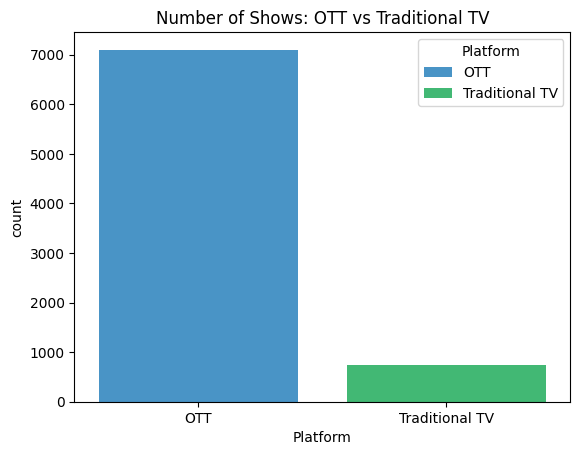

Average Ratings:
 Platform
OTT               8.332018
Traditional TV    7.992123
Name: Rating, dtype: float64


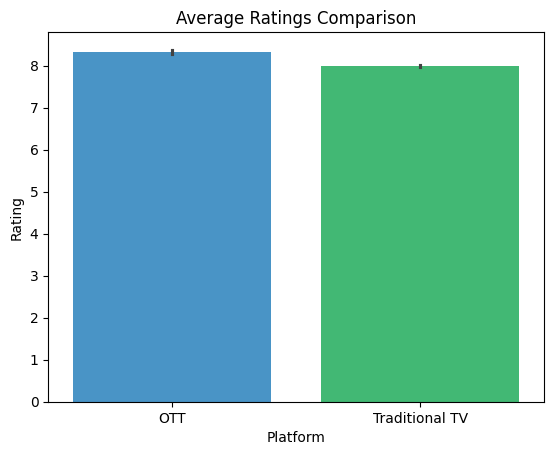

In [10]:
sns.countplot(data=combined_df, x='Platform', hue='Platform', palette=['#3498db', '#2ecc71'], legend=True)
plt.title('Number of Shows: OTT vs Traditional TV')
plt.show()


if 'Rating' in combined_df.columns:
    avg_ratings = combined_df.groupby('Platform')['Rating'].mean()

    print("Average Ratings:\n", avg_ratings)

    sns.barplot(x='Platform', y='Rating', hue='Platform', data=combined_df, estimator=np.mean, palette=['#3498db', '#2ecc71'], legend=False)
    plt.title('Average Ratings Comparison')
    plt.show()

<p>
The <b>first bar plot</b> shows the distribution of the number of shows available on OTT platforms compared to Traditional TV.

It is clear that:

OTT platforms (like Netflix) have a significantly higher number of shows—over 7000 titles,which could be because they have bothh original and traditional tv shows on their platform.

Traditional TV has a much smaller content library in comparison, with fewer than 1,000 titles(in case of the available data).

This reflects the nature of OTT services, which typically offer large, on-demand libraries, whereas traditional TV is often curated and limited. 
</p>
<p>

The <b>second bar plot</b> compares the average show ratings between OTT and Traditional TV.

<b>Key observations:</b>

OTT shows have a slightly higher average rating (over 8 on average).
Traditional TV shows have an average rating around 7.9.
This suggests:
OTT content may be perceived as slightly higher in quality or better received by audiences on average.</p>

<h3>Plot 3</h3>

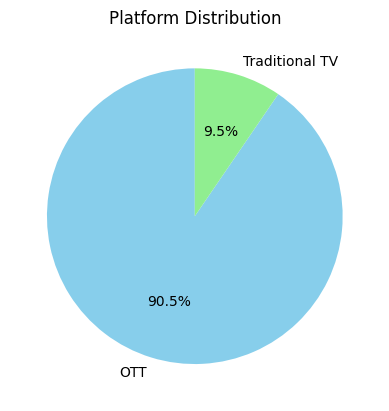

In [11]:
combined_df['Platform'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Platform Distribution')
plt.ylabel('')
plt.show()

<p>The pie chart above visualizes the proportion of shows available on OTT platforms compared to Traditional TV in the combined dataset.<br
<b>Key Notes</b>:
OTT platforms account for the vast majority of shows with 90.5% of the total content.

Traditional TV represents only 9.5% of the total.<p>

<h4>Finding shows that exist on both platforms</h4>

2.43% of Traditional TV shows are also available on OTT.


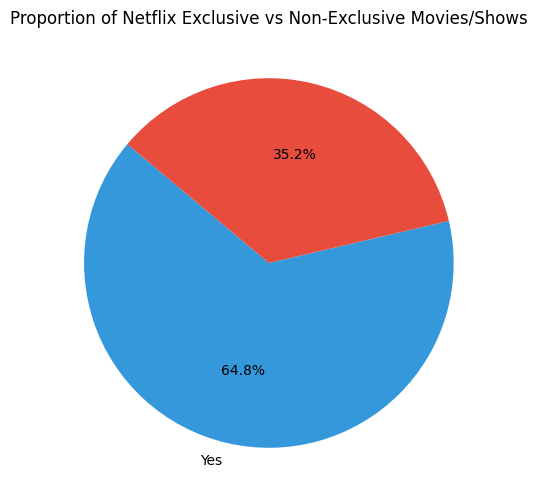

In [12]:
netflix_titles = set(netflix_df['Title'].str.lower().str.strip())
tv_titles = set(tv_df['Title'].str.lower().str.strip())

common_titles = netflix_titles.intersection(tv_titles)
percent_on_ott = (len(common_titles) / len(tv_titles)) * 100
print(f"{percent_on_ott:.2f}% of Traditional TV shows are also available on OTT.")

exclusive_counts = netflix_df['Netflix Exclusive'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(exclusive_counts, labels=exclusive_counts.index, autopct='%1.1f%%', startangle=140, colors=['#3498db', '#e74c3c'])
plt.title('Proportion of Netflix Exclusive vs Non-Exclusive Movies/Shows')
plt.show()


<h5><p>Here we can clearly see that abuot 65% of the shows are netflix exclusive which means to consume that content people would have too stream it there itself and this incraeases the streaming traffic on the streaming site.</p></h5>

<h3>Plot 4</h3>
<p><h5>Coparison of releases year by year by traditional tv and ott</h5></p>

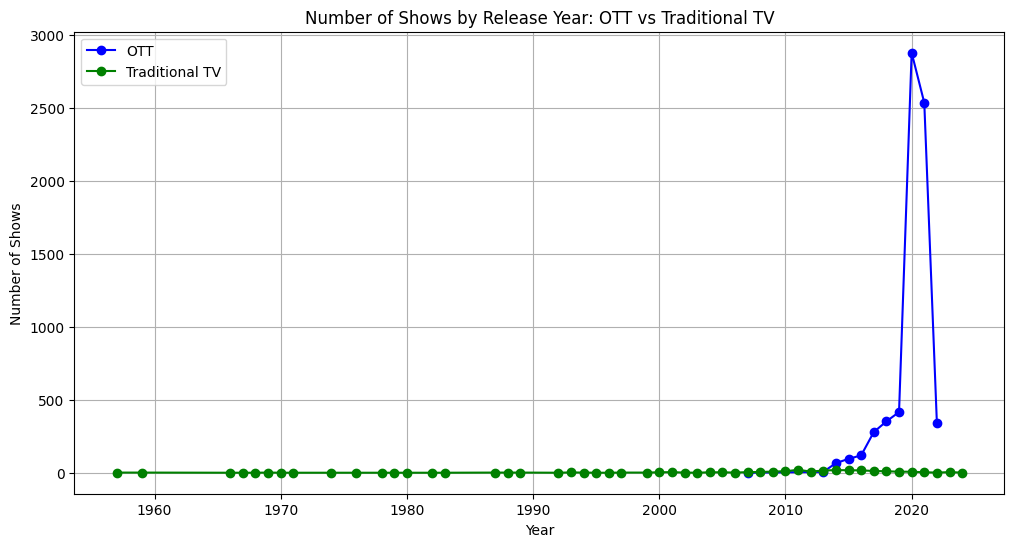

In [13]:
netflix_df['Release_Year'] = pd.to_datetime(netflix_df['Netflix Release Date'], errors='coerce').dt.year
tv_df['Release_Year'] = pd.to_datetime(tv_df['Premiere Date'], errors='coerce').dt.year

ott_years = netflix_df['Release_Year'].value_counts().sort_index()
tv_years = tv_df['Release_Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(ott_years.index, ott_years.values, label='OTT', marker='o', color='blue')
plt.plot(tv_years.index, tv_years.values, label='Traditional TV', marker='o', color='green')
plt.title('Number of Shows by Release Year: OTT vs Traditional TV')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.legend()
plt.grid()
plt.show()

<p><b>OTT Platforms (Blue Line)</b>:
OTT content barely existed before 2010, reflecting the relatively recent emergence of streaming services.
There is a sharp surge in the number of OTT shows starting around 2015, with an explosive growth between 2018 and 2021.
The peak shows nearly 3,000 new OTT releases in a single year, which reflects the aggressive expansion of streaming platforms.
<b>It should also be noted there is a sharp dedcline in ott streaming after 2020 which means for some reason they also became unpopular in comparison to prior release rate or it could also be the affect of covid 19 taht less shows were producced.</b>

<b>Traditional TV (Green Line)</b>:
Traditional TV maintains a consistent but very low output across decades, with no significant spikes.
The flat trend suggests that traditional television content has not grown significantly over time in this dataset.
</p>

<h3>Plot 5</h3>
<h5>Cummulative growth comparison</h5>

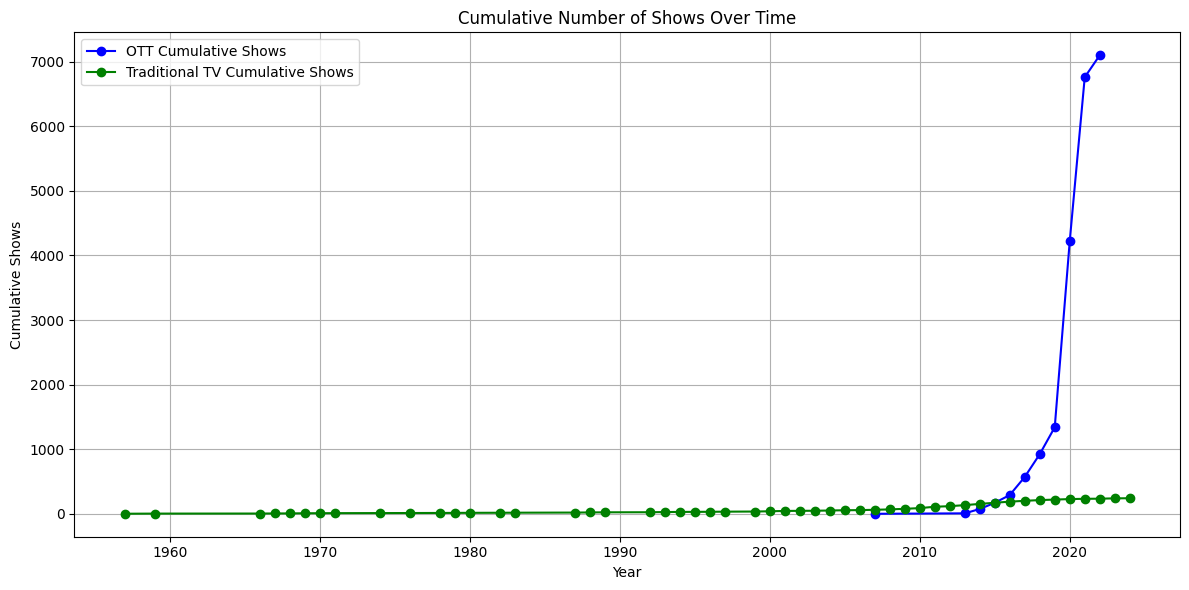

In [14]:
ott_cumulative = netflix_df.groupby('Release_Year').size().cumsum()
tv_cumulative = tv_df.groupby('Release_Year').size().cumsum()

plt.figure(figsize=(12,6))
plt.plot(ott_cumulative.index, ott_cumulative.values, label='OTT Cumulative Shows', marker='o', color='blue')
plt.plot(tv_cumulative.index, tv_cumulative.values, label='Traditional TV Cumulative Shows', marker='o', color='green')
plt.title('Cumulative Number of Shows Over Time')
plt.xlabel('Year')
plt.ylabel('Cumulative Shows')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()


<p><b>OTT Platforms (Blue Line)</b>:

The cumulative count remained flat until around 2010,which shows late entry of OTT services.
From 2015 onwards, there is an exponential increase in the cumulative number of OTT shows, reaching over 7,000 shows in the most recent years.
This sharp upward trajectory indicates the explosive growth  of streaming services.

<b>Traditional TV (Green Line)</b>:
The cumulative growth is steady but extremely slow, remaining well below 500 shows across multiple decades.
The traditional TV content base has seen minimal expansion compared to OTT platforms.</p>

<h3>Plot:6 Correlation Mattrix</h3>

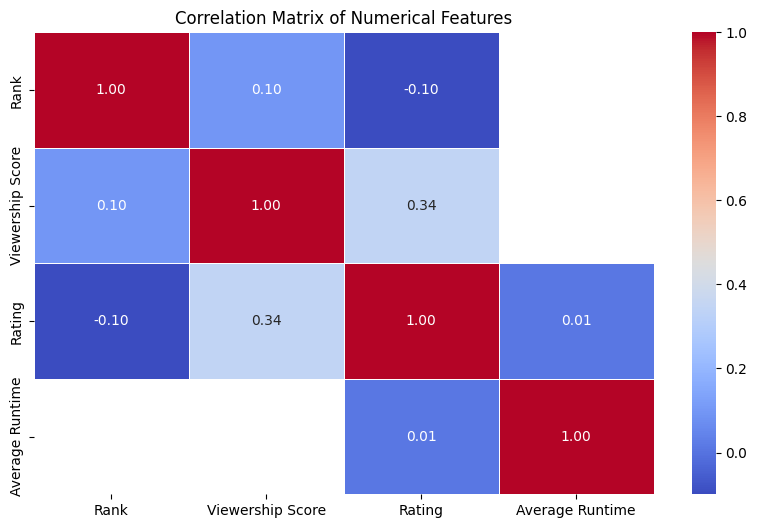

In [15]:
numeric_cols = combined_df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

<h3>Plot 7</h3>

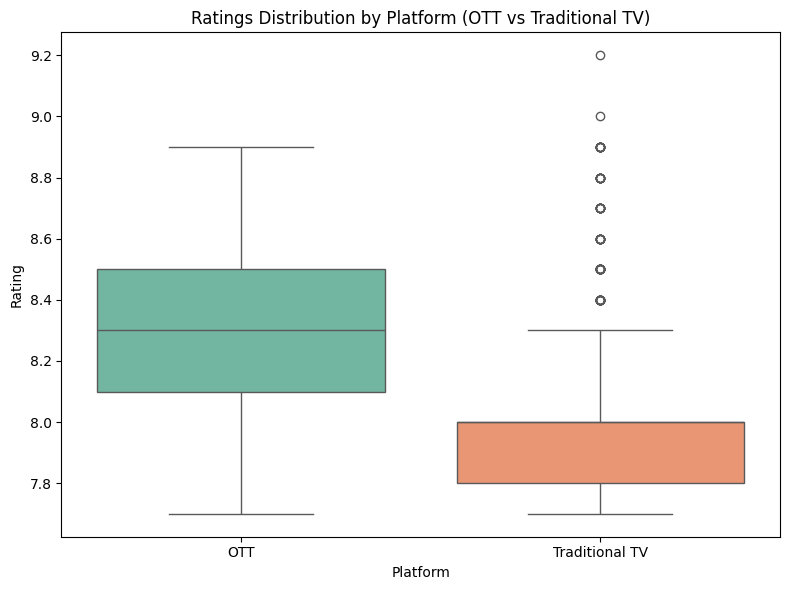

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(data=combined_df, x='Platform', y='Rating', hue='Platform', palette='Set2', legend=False)
plt.title('Ratings Distribution by Platform (OTT vs Traditional TV)')
plt.ylabel('Rating')
plt.xlabel('Platform')
plt.tight_layout()
plt.show()


<p>This box plot visualizes the distribution of Ratings.

Key observations from the box plot:

<b> OTT Platform</b>:
   The median rating for OTT content is approximately 8.3.</li>
   The interquartile range (IQR), represented by the box, spans from roughly 8.1 to 8.5. 
<b>Traditional TV Platform:</b>
     The median rating for Traditional TV content is lower, at around 7.9.
     The IQR for Traditional TV is narrower, ranging from about 7.8 to 8.0.
<br>
<b><i>Thus, this suggests that people are generally liking the content on ott better than that of traditional tv.</i></b>
</p>

<h3>Conclusion</h3>
<p>We can clearly see from the above analysis that from the dawn of online streaming service since 2008, there hass been a decline in the popularity of traditional tv. <br>
Although we can't directly say that there has been compromise in the quality of content published/presented on traditional tv but the average ratings of movies/tv-shows online simply reflects that audiences prefer the streaming platforms a bit more.<br>
It is also worth noticing that this shit was exponentially boosted a little before the pandemic(Covid 19) and for reasons out of the scope of this analysis came crashing down in just the years after the pandemic. </p>